# Bevölkerung nach Stadtkreis


### Kurzbeschreibung
Wirtschaftliche Wohnbevölkerung der Stadt Zürich nach Stadtkreis und Jahr.

Datum: 04.02.205


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_kreis_od3242

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_kreis_od3242


### Importiere die notwendigen Packages

In [11]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [12]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [13]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [14]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [15]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [16]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [17]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [18]:
package_name = "bev_bestand_jahr_kreis_od3242"

In [19]:
data2betested = mypy_dl.load_data(
    status = 'prod'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV324OD3242"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_kreis_od3242/download/BEV324OD3242.csv


 **Überprüfe die Metadaten:**

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_kreis_od3242 

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/bev_bestand_jahr_kreis_od3242 

data_source: web


In [20]:
data2betested.head(2).T

,0,1
StichtagDatJahr,1993-01-01 00:00:00,1993-01-01 00:00:00
KreisSort,1,2
KreisCd,1,2
KreisLang,Kreis 1,Kreis 2
AnzBestWir,5961,28607


Berechne weitere Attribute falls notwendig

In [21]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr        datetime64[ns]
KreisSort                       int64
KreisCd                         int64
KreisLang                      object
AnzBestWir                      int64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_end               datetime64[ns]
Jahr_nbr                        int32
dtype: object

In [22]:
data2betested.head(2).T

,383,377
StichtagDatJahr,2024-01-01 00:00:00,2024-01-01 00:00:00
KreisSort,12,6
KreisCd,12,6
KreisLang,Kreis 12,Kreis 6
AnzBestWir,32871,36161
StichtagDatJahr_str,2024-01-01,2024-01-01
Jahr,2024-01-01 00:00:00,2024-01-01 00:00:00
Jahr_end,2024-12-31 00:00:00,2024-12-31 00:00:00
Jahr_nbr,2024,2024


Minimales und maximales Jahr im Datensatz

In [23]:
data_max_jahr = str(max(data2betested.Jahr).year)
data_min_jahr = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_jahr} und ein Maximumjahr von {data_max_jahr}")

Die Daten haben ein Minimumjahr von 1993 und ein Maximumjahr von 2024


In [24]:
data_max_date = max(data2betested.Jahr_end).strftime('%Y-%m-%d')
data_min_date = min(data2betested.Jahr_end).strftime('%Y-%m-%d')


print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1993-12-31 und ein Maximumjahr von 2024-12-31


### Einfache Datentests

In [25]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 384 entries, 383 to 0
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   StichtagDatJahr      384 non-null    datetime64[ns]
 1   KreisSort            384 non-null    int64         
 2   KreisCd              384 non-null    int64         
 3   KreisLang            384 non-null    object        
 4   AnzBestWir           384 non-null    int64         
 5   StichtagDatJahr_str  384 non-null    object        
 6   Jahr                 384 non-null    datetime64[ns]
 7   Jahr_end             384 non-null    datetime64[ns]
 8   Jahr_nbr             384 non-null    int32         
dtypes: datetime64[ns](3), int32(1), int64(3), object(2)
memory usage: 71.7 KB


In [26]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 384 rows (observations) and 9 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [27]:
data2betested.describe()

,StichtagDatJahr,KreisSort,KreisCd,AnzBestWir,Jahr,Jahr_end,Jahr_nbr
count,384,384,384,384,384,384,384
mean,2008-07-02 00:00:00,6,6,32577,2008-07-02 00:00:00,2009-07-01 06:00:00,2008
min,1993-01-01 00:00:00,1,1,5536,1993-01-01 00:00:00,1993-12-31 00:00:00,1993
25%,2000-10-01 12:00:00,4,4,24503,2000-10-01 12:00:00,2001-09-30 18:00:00,2001
50%,2008-07-02 00:00:00,6,6,31676,2008-07-02 00:00:00,2009-07-01 12:00:00,2008
75%,2016-04-01 12:00:00,9,9,42209,2016-04-01 12:00:00,2017-04-01 06:00:00,2016
max,2024-01-01 00:00:00,12,12,79678,2024-01-01 00:00:00,2024-12-31 00:00:00,2024
std,NaN,3,3,16173,NaN,NaN,9


Welches sind die Quartiere ohne Werte bei BEW?

In [28]:
data2betested[np.isnan(data2betested.AnzBestWir)]

,StichtagDatJahr,KreisSort,KreisCd,KreisLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [29]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [30]:
data2betested.index.year.unique()

Index([1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024],
      dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [31]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number'))
except:
    print("No categorical data in dataset.")

,KreisLang,StichtagDatJahr_str,Jahr,Jahr_end
count,384,384,384,384
unique,12,32,NaN,NaN
top,Kreis 1,1993-01-01,NaN,NaN
freq,32,12,NaN,NaN
mean,NaN,NaN,2008-07-02 00:00:00,2009-07-01 06:00:00
min,NaN,NaN,1993-01-01 00:00:00,1993-12-31 00:00:00
25%,NaN,NaN,2000-10-01 12:00:00,2001-09-30 18:00:00
50%,NaN,NaN,2008-07-02 00:00:00,2009-07-01 12:00:00
75%,NaN,NaN,2016-04-01 12:00:00,2017-04-01 06:00:00
max,NaN,NaN,2024-01-01 00:00:00,2024-12-31 00:00:00


Beschreibe numerische Attribute

In [32]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,KreisSort,KreisCd,AnzBestWir,Jahr_nbr
count,384,384,384,384
mean,6,6,"32,577","2,008"
std,3,3,"16,173",9
min,1,1,"5,536","1,993"
25%,4,4,"24,503","2,001"
50%,6,6,"31,676","2,008"
75%,9,9,"42,209","2,016"
max,12,12,"79,678","2,024"


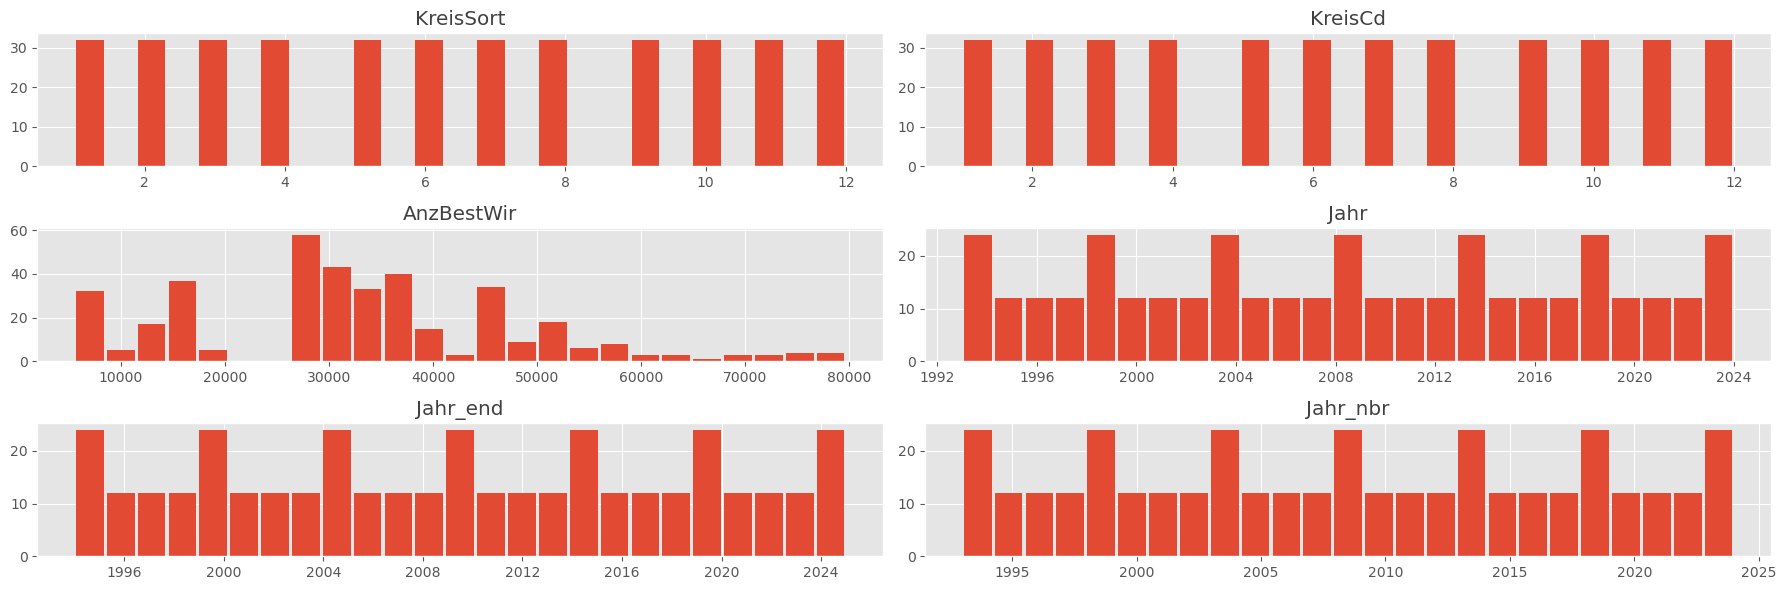

In [33]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [34]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,KreisSort,KreisCd,KreisLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,,


### Nullwerte und Missings?

In [35]:
data2betested.isnull().sum()

KreisSort              0
KreisCd                0
KreisLang              0
AnzBestWir             0
StichtagDatJahr_str    0
Jahr                   0
Jahr_end               0
Jahr_nbr               0
dtype: int64

In [36]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [37]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr', 'Jahr_end']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,Jahr_end,sum_AnzBestWir
0,2024-01-01,2024,2024-12-31,448664
1,2023-01-01,2023,2023-12-31,447082
2,2022-01-01,2022,2022-12-31,443037


In [38]:
agg_raum = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['KreisSort', 'KreisLang',]) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('KreisSort', ascending=False) 
agg_raum.reset_index().head(3)

,KreisSort,KreisLang,sum_AnzBestWir
0,12,Kreis 12,927072
1,11,Kreis 11,2016738
2,10,Kreis 10,1169496


In [39]:
agg_raum_zeit = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr_nbr', 'Jahr_end', 'KreisSort', 'KreisLang',]) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('Jahr_nbr', ascending=True) 
agg_raum_zeit.reset_index().head(3)

,Jahr_nbr,Jahr_end,KreisSort,KreisLang,sum_AnzBestWir
0,1994,1994-12-31,1,Kreis 1,5827
1,1994,1994-12-31,12,Kreis 12,27565
2,1994,1994-12-31,11,Kreis 11,52474


In [40]:
data2betested.reset_index().columns

Index(['StichtagDatJahr', 'KreisSort', 'KreisCd', 'KreisLang', 'AnzBestWir', 'StichtagDatJahr_str',
       'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

### Visualisierungen nach Zeitausschnitten

#### Entwicklung der Wohnbevölkerung nach Quartier

In [41]:
#data2betested.loc[data_min_date:'1970']\
#     .query('QuarSort < 40')\
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'KreisSort', 'KreisLang',]) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg1.reset_index().head(3)

,StichtagDatJahr,KreisSort,KreisLang,sum_WBev
0,1994-01-01,1,Kreis 1,5827
1,1994-01-01,12,Kreis 12,27565
2,1994-01-01,11,Kreis 11,52474


In [42]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('KreisSort', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "KreisLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Wohnbevölkerung nach Stadtkreis, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

##### Kombinierte Grafik in Altair

In [43]:
# Kombiniere die Grafiken horizontal
top_row = alt.hconcat(grafik1, grafik1)
#combined_chart = alt.vconcat(top_row,grafik3)
combined_chart = alt.vconcat(grafik1, grafik1, spacing=20)

# Optional: Füge einen Titel für die gesamte Grafik hinzu
final_chart = combined_chart.properties(
    title="Alle Teilgrafiken in einer zusammengesetzt:    ",  
    background="#FDFDFD",
    padding={"left": 20, "top": 20, "right": 20, "bottom": 20},
    autosize={"type": "fit", "contains": "padding"}
)
#Legenden nicht zusammenfügen
final_chart = final_chart.resolve_scale(
    color='independent',
    shape='independent',
    size='independent'
)

# Zeigen Sie die Grafik an
final_chart

alt.VConcatChart(...)

#### Faced Grids

In [44]:
myFG = data2betested.reset_index().query('KreisSort != 0')
myFG

,StichtagDatJahr,KreisSort,KreisCd,KreisLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,1993-01-01,1,1,Kreis 1,5961,1993-01-01,1993-01-01,1993-12-31,1993
1,1993-01-01,4,4,Kreis 4,28300,1993-01-01,1993-01-01,1993-12-31,1993
2,1993-01-01,5,5,Kreis 5,11495,1993-01-01,1993-01-01,1993-12-31,1993
3,1993-01-01,7,7,Kreis 7,33788,1993-01-01,1993-01-01,1993-12-31,1993
4,1993-01-01,3,3,Kreis 3,46340,1993-01-01,1993-01-01,1993-12-31,1993
...,...,...,...,...,...,...,...,...,...
379,2024-01-01,9,9,Kreis 9,60137,2024-01-01,2024-01-01,2024-12-31,2024
380,2024-01-01,10,10,Kreis 10,41544,2024-01-01,2024-01-01,2024-12-31,2024
381,2024-01-01,11,11,Kreis 11,79678,2024-01-01,2024-01-01,2024-12-31,2024
382,2024-01-01,4,4,Kreis 4,29518,2024-01-01,2024-01-01,2024-12-31,2024


In [45]:
data2betested.columns

Index(['KreisSort', 'KreisCd', 'KreisLang', 'AnzBestWir', 'StichtagDatJahr_str', 'Jahr',
       'Jahr_end', 'Jahr_nbr'],
      dtype='object')

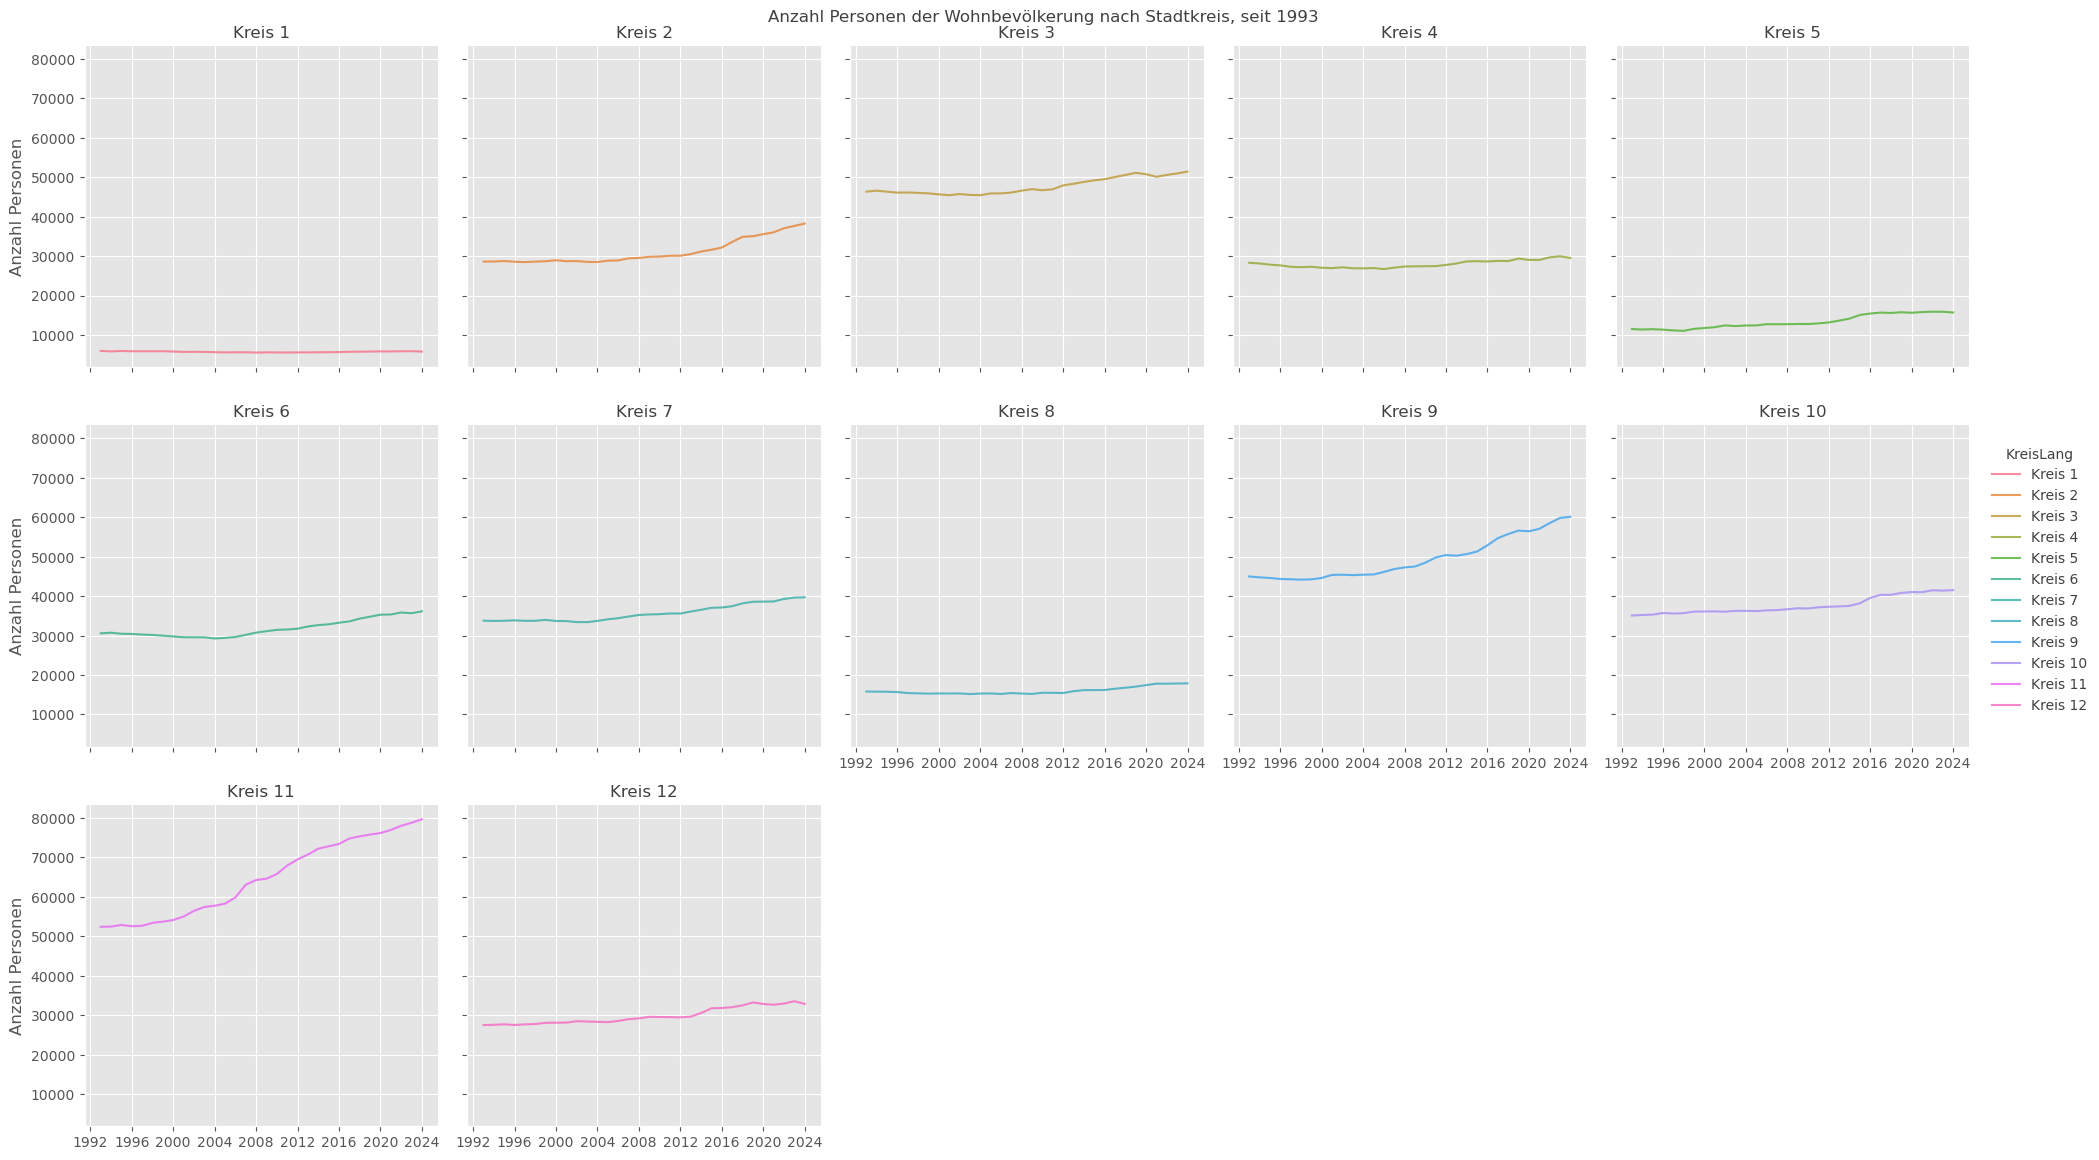

In [46]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('KreisSort', ascending=True)
    ,col = "KreisLang"
    ,hue = "KreisLang"
    ,col_wrap = 5
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "AnzBestWir"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Anzahl Personen der Wohnbevölkerung nach Stadtkreis, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [47]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [48]:
# Extrahiere die Top-Fahrzeugmarken
zuzugsgebiet = data2betested['KreisLang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(zuzugsgebiet):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Kreis 1': '#0017BF', 'Kreis 4': '#0072D7', 'Kreis 5': '#00A5D2', 'Kreis 7': '#5E359A', 'Kreis 3': '#BA0062', 'Kreis 6': '#DA5563', 'Kreis 12': '#00615D', 'Kreis 8': '#00770F', 'Kreis 11': '#7BA600', 'Kreis 2': '#7B4100', 'Kreis 9': '#DC5500', 'Kreis 10': '#DA9C00'}


In [49]:
data2betested.columns

Index(['KreisSort', 'KreisCd', 'KreisLang', 'AnzBestWir', 'StichtagDatJahr_str', 'Jahr',
       'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [50]:
myTM = data2betested.loc[data_min_date:data_max_date].reset_index() \

myTM.reset_index().head(2)

,index,StichtagDatJahr,KreisSort,KreisCd,KreisLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,0,1994-01-01,6,6,Kreis 6,30743,1994-01-01,1994-01-01,1994-12-31,1994
1,1,1994-01-01,1,1,Kreis 1,5827,1994-01-01,1994-01-01,1994-12-31,1994


In [51]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTM.reset_index()
    ,levels=['KreisLang','Jahr_nbr']
    ,values="AnzBestWir"
    ,color="AnzBestWir"
    #, color_continuous_scale='Blues'
    ,color_discrete_map={'(?)':'lightgrey', 'Wohnen':'lightblue'}   
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Wohnbevölkerung nach Stadtkreis und Jahr, "+data_max_date
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x0000020E79D06990>, 'KreisLang', 'Jahr_nbr']
Typ von path: <class 'list'>


In [52]:
myTM2 = data2betested.loc[data_max_jahr]

myTM2.reset_index().head(2)

,StichtagDatJahr,KreisSort,KreisCd,KreisLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,2024-01-01,6,6,Kreis 6,36161,2024-01-01,2024-01-01,2024-12-31,2024
1,2024-01-01,1,1,Kreis 1,5769,2024-01-01,2024-01-01,2024-12-31,2024


In [53]:
treeMap2= mypy_dv.plot_px_treemap(
    data=myTM2.reset_index()
    ,levels=['KreisLang']
    ,values="AnzBestWir"
    ,color="KreisLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc 
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Wohnbevölkerung nach Stadtkreis am "+data_max_date
)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x0000020E780B5750>, 'KreisLang']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=1233&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------